Mencegah undefitting :
1. Menyederhanakan Model : Mengurangi Jumlah layer NN 
2. Memperbanyakan Petahihan : Bisa menggunakan Data Augmentation dimana datanya akan Bervariasi yang membuat Model Belajar Banyak Skenario bukan Menghafal
3. Menambah Epoch : dimana Model akan diberikan Waktu Lebih Untuk mempelajari Data 

In [2]:
import requests
import zipfile
from pathlib import Path

# Setup path to data folder
data_path = Path("data/")
image_path = data_path / "pizza_steak_sushi_20_percent"

# If the image folder doesn't exist, download it and prepare it... 
if image_path.is_dir():
    print(f"{image_path} directory exists.")
else:
    print(f"Did not find {image_path} directory, creating one...")
    image_path.mkdir(parents=True, exist_ok=True)
    
    # Download pizza, steak, sushi data
    with open(data_path / "pizza_steak_sushi_20_percent.zip", "wb") as f:
        request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi_20_percent.zip")
        print("Downloading pizza, steak, sushi data...")
        f.write(request.content)

    # Unzip pizza, steak, sushi data
    with zipfile.ZipFile(data_path / "pizza_steak_sushi_20_percent.zip", "r") as zip_ref:
        print("Unzipping pizza, steak, sushi data...") 
        zip_ref.extractall(image_path)

data/pizza_steak_sushi_20_percent directory exists.


In [3]:
import os 
def walk_through_dir(dir_path):

  for dirpath, dirnames, filenames in os.walk(dir_path):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

walk_through_dir(image_path)

There are 2 directories and 0 images in 'data/pizza_steak_sushi_20_percent'.
There are 3 directories and 0 images in 'data/pizza_steak_sushi_20_percent/train'.
There are 0 directories and 146 images in 'data/pizza_steak_sushi_20_percent/train/steak'.
There are 0 directories and 150 images in 'data/pizza_steak_sushi_20_percent/train/sushi'.
There are 0 directories and 154 images in 'data/pizza_steak_sushi_20_percent/train/pizza'.
There are 3 directories and 0 images in 'data/pizza_steak_sushi_20_percent/test'.
There are 0 directories and 58 images in 'data/pizza_steak_sushi_20_percent/test/steak'.
There are 0 directories and 46 images in 'data/pizza_steak_sushi_20_percent/test/sushi'.
There are 0 directories and 46 images in 'data/pizza_steak_sushi_20_percent/test/pizza'.


In [4]:
import torch

# cek apakah cuda tersedia jika tidak pakai cpu

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [5]:
train_dir = image_path / "train"
test_dir = image_path / "test"

train_dir, test_dir

(PosixPath('data/pizza_steak_sushi_20_percent/train'),
 PosixPath('data/pizza_steak_sushi_20_percent/test'))

Random Image Path : data/pizza_steak_sushi_20_percent/train/steak/1212161.jpg
Image class: steak
Image height: 509
Image Width: 512


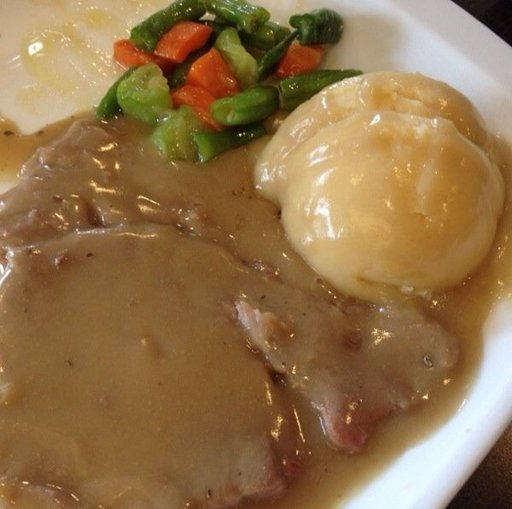

In [6]:
import random 
from PIL import Image

random.seed(42)

image_path_list = list(image_path.glob("*/*/*.jpg"))
random_image_path = random.choice(image_path_list)
image_class = random_image_path.parent.stem

img = Image.open(random_image_path)

print(f"Random Image Path : {random_image_path}")
print(f"Image class: {image_class}")
print(f"Image height: {img.height}")
print(f"Image Width: {img.width}")
img

(np.float64(-0.5), np.float64(511.5), np.float64(508.5), np.float64(-0.5))

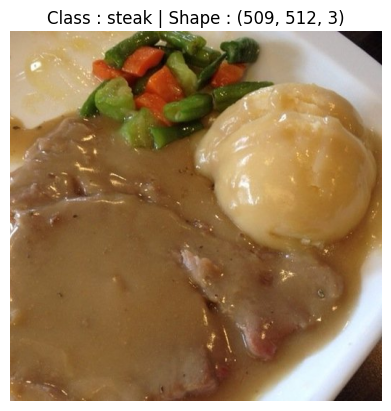

In [7]:
import numpy as np
import matplotlib.pyplot as plt

img_as_array = np.asarray(img)

plt.imshow(img_as_array)
plt.title(f"Class : {image_class} | Shape : {img_as_array.shape}")
plt.axis(False)

Helper Plot Menampilkan Original Image vs Transform

In [8]:
def plot_transformed_images(image_paths, transform, n=3, seed=42):
  random.seed(seed)
  random_image_path = random.sample(image_paths, k=n)
  for image_path in random_image_path:
    with Image.open(image_path) as f:
      fig, ax = plt.subplots(1, 2) # baris 1 , kolom 2
      ax[0].imshow(f)
      ax[0].set_title(f"Original \nSize: {f.size}")
      ax[0].axis("off")

      # default pytorch CHW ubah ke matplotlib support HWC
      transform_image = transform(f).permute(1,2,0)
      ax[1].imshow(transform_image)
      ax[1].set_title(f"Transformed \nSize: {f.size}")
      ax[1].axis("off")

      fig.suptitle(f"Class : {image_path.parent.stem}")

In [9]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [10]:
train_transforms = transforms.Compose([
  transforms.Resize((64, 64)),
  transforms.TrivialAugmentWide(), # default num_magnitude_bins = 31
  transforms.ToTensor()
])

test_transforms = transforms.Compose([
  transforms.Resize((64,64)),
  transforms.ToTensor()
])

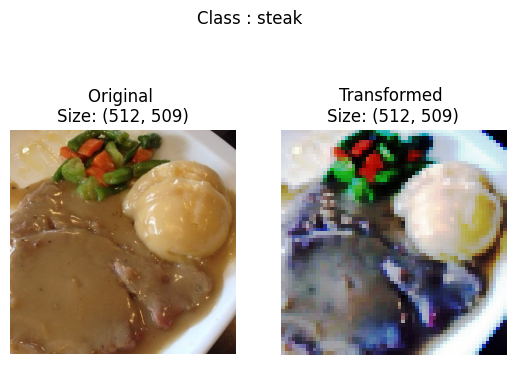

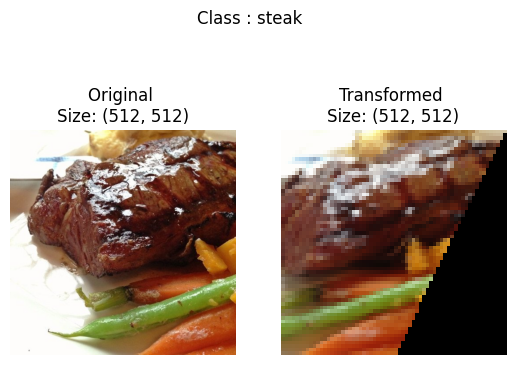

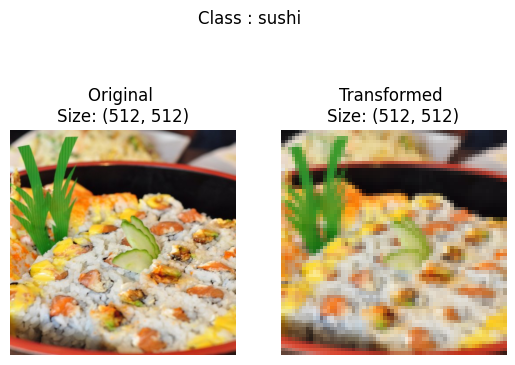

In [11]:
plot_transformed_images(image_paths=image_path_list,
                        transform=train_transforms,
                        n=3)

Loading Image Data

In [12]:
from torchvision import datasets
train_data = datasets.ImageFolder(root=train_dir,
                                  transform=train_transforms)

test_data = datasets.ImageFolder(root=test_dir,
                                 transform=test_transforms)

print(f"Train data:\n{train_data}\nTest Data:\n{test_data}")

Train data:
Dataset ImageFolder
    Number of datapoints: 450
    Root location: data/pizza_steak_sushi_20_percent/train
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               TrivialAugmentWide(num_magnitude_bins=31, interpolation=InterpolationMode.NEAREST, fill=None)
               ToTensor()
           )
Test Data:
Dataset ImageFolder
    Number of datapoints: 150
    Root location: data/pizza_steak_sushi_20_percent/test
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               ToTensor()
           )


In [13]:
class_names = train_data.classes
class_dict = train_data.class_to_idx
class_names, class_dict

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

In [14]:
len(train_data), len(test_data)

(450, 150)

Ubah Loaded Images menjadi Dataloader

In [15]:
import os
from torch.utils.data import DataLoader

BATCH_SIZE = 32
NUM_WORKERS = os.cpu_count()

train_dataloader = DataLoader(dataset=train_data,
                              num_workers=NUM_WORKERS,
                              batch_size=BATCH_SIZE,
                              shuffle=True)

test_dataloader = DataLoader(dataset=test_data,
                             num_workers=NUM_WORKERS,
                             batch_size=BATCH_SIZE,
                             shuffle=False)

train_dataloader, test_dataloader



(<torch.utils.data.dataloader.DataLoader at 0x7b3825e20aa0>,
 <torch.utils.data.dataloader.DataLoader at 0x7b380584bbc0>)

In [16]:
from torch import nn

class TinyVGG(nn.Module):
  def __init__(self, input_shape: int, hidden_units: int, output_shape:int):
    super().__init__()

    self.block_1 = nn.Sequential(
      nn.Conv2d(in_channels=input_shape, out_channels=hidden_units, kernel_size=3, padding=1, stride=1),
      nn.ReLU(),
      nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, padding=1, stride=1),
      nn.ReLU(),
      nn.MaxPool2d(kernel_size=2, stride=2)
    )

    self.block_2 = nn.Sequential(
      nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, padding=1, stride=1),
      nn.ReLU(),
      nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, padding=1, stride=1),
      nn.ReLU(),
      nn.MaxPool2d(kernel_size=2, stride=2)
    )

    self.classifier = nn.Sequential(
      nn.Flatten(),
      nn.Linear(in_features=hidden_units * 16 * 16, out_features=output_shape)
    )

  def forward(self, x):
    x = self.block_1(x)
    x = self.block_2(x)
    x = self.classifier(x)
    return x

In [17]:
model_0 = TinyVGG(input_shape=3,
                hidden_units=10,
                output_shape=len(train_data.classes))

model_0

TinyVGG(
  (block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2560, out_features=3, bias=True)
  )
)

Helper Train Step

In [18]:
def train_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer):

  model.train()

  train_loss, train_acc = 0, 0

  for batch, (X, y) in enumerate(dataloader):
    X, y = X.to(device), y.to(device)

    y_pred = model(X)

    loss = loss_fn(y_pred, y)
    train_loss += loss.item()

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
    train_acc += (y_pred_class == y).sum().item() / len(y_pred)

  train_loss = train_loss / len(dataloader)
  train_acc = train_acc / len(dataloader)
  return train_loss, train_acc

In [19]:
def test_step(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module):

  model.eval()

  test_loss, test_acc = 0,0

  with torch.inference_mode():
    for batch, (X, y) in enumerate(dataloader):
      X, y = X.to(device), y.to(device)

      test_pred_logits = model(X)

      loss = loss_fn(test_pred_logits, y)
      test_loss += loss.item()

      test_pred_labels = test_pred_logits.argmax(dim=1)
      test_acc = ((test_pred_labels == y).sum().item() / len(test_pred_labels))

    test_loss = test_loss / len(dataloader)
    test_acc = test_acc / len(dataloader)
    return test_loss, test_acc

Train Helper

In [20]:
from tqdm.auto import tqdm

def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module = torch.nn.CrossEntropyLoss(),
          epochs: int = 5):

  results = {"train_loss": [],
             "train_acc": [],
             "test_loss": [],
             "test_acc": []}

  for epoch in tqdm(range(epochs)):
    train_loss, train_acc = train_step(model=model,
                                       dataloader=train_dataloader,
                                       loss_fn=loss_fn,
                                       optimizer=optimizer)

    test_loss, test_acc = test_step(model=model,
                                    dataloader=test_dataloader,
                                    loss_fn=loss_fn)

    
    print(f"Epoch : {epoch} | train_loss: {train_loss:.4f} | train_acc: {train_acc:.4f} | test_loss: {test_loss:.4f} | test_acc: {test_acc:.4f}")

    results["train_loss"].append(train_loss.item() if isinstance(train_loss, torch.nn.Module) else train_loss)
    results["train_acc"].append(train_acc.item() if isinstance(train_acc, torch.nn.Module) else train_acc)
    results["test_loss"].append(test_loss.item() if isinstance(test_loss, torch.nn.Module) else test_loss)
    results["test_acc"].append(test_acc.item() if isinstance(test_acc, torch.nn.Module) else test_acc)

  return results

Mencoba Eksperimen Pengubahan dengan Penambahan Pada Epochs 
1. ```model_0_result_0``` = 5 Epoch
2. ```model_0_result_1``` = 20 Epoch
3. ```model_0_result_2``` = 50 Epoch

In [21]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

NUM_EPOCHS = 5

model_0 = TinyVGG(input_shape=3,
                  hidden_units=10,
                  output_shape=len(train_data.classes)).to(device)

loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_0.parameters(), lr=0.001)

from timeit import default_timer as timer
start_time = timer()

model_0_results_0 = train(model=model_0,
                        train_dataloader=train_dataloader,
                        test_dataloader=test_dataloader,
                        optimizer=optimizer,
                        loss_fn=loss_fn,
                        epochs=NUM_EPOCHS)

end_time = timer()
print(f"Total training time: {end_time-start_time:.3f} seconds")

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch : 0 | train_loss: 1.1077 | train_acc: 0.3438 | test_loss: 1.0972 | test_acc: 0.0000
Epoch : 1 | train_loss: 1.1019 | train_acc: 0.3125 | test_loss: 1.1009 | test_acc: 0.0000
Epoch : 2 | train_loss: 1.0995 | train_acc: 0.3354 | test_loss: 1.0970 | test_acc: 0.0000
Epoch : 3 | train_loss: 1.0992 | train_acc: 0.2687 | test_loss: 1.0987 | test_acc: 0.0727
Epoch : 4 | train_loss: 1.0977 | train_acc: 0.3479 | test_loss: 1.1030 | test_acc: 0.0000
Total training time: 9.553 seconds


In [22]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

NUM_EPOCHS = 20

model_0 = TinyVGG(input_shape=3,
                  hidden_units=10,
                  output_shape=len(train_data.classes)).to(device)

loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_0.parameters(), lr=0.001)

from timeit import default_timer as timer
start_time = timer()

model_0_results_1 = train(model=model_0,
                        train_dataloader=train_dataloader,
                        test_dataloader=test_dataloader,
                        optimizer=optimizer,
                        loss_fn=loss_fn,
                        epochs=NUM_EPOCHS)

end_time = timer()
print(f"Total training time: {end_time-start_time:.3f} seconds")

  0%|          | 0/20 [00:00<?, ?it/s]

Epoch : 0 | train_loss: 1.1077 | train_acc: 0.3438 | test_loss: 1.0972 | test_acc: 0.0000
Epoch : 1 | train_loss: 1.1019 | train_acc: 0.3146 | test_loss: 1.1009 | test_acc: 0.0000
Epoch : 2 | train_loss: 1.0995 | train_acc: 0.3354 | test_loss: 1.0970 | test_acc: 0.0000
Epoch : 3 | train_loss: 1.0992 | train_acc: 0.3042 | test_loss: 1.0986 | test_acc: 0.1909
Epoch : 4 | train_loss: 1.0973 | train_acc: 0.3688 | test_loss: 1.1027 | test_acc: 0.0000
Epoch : 5 | train_loss: 1.0979 | train_acc: 0.3187 | test_loss: 1.0993 | test_acc: 0.0091
Epoch : 6 | train_loss: 1.1017 | train_acc: 0.3146 | test_loss: 1.0976 | test_acc: 0.0000
Epoch : 7 | train_loss: 1.0971 | train_acc: 0.3354 | test_loss: 1.0945 | test_acc: 0.0000
Epoch : 8 | train_loss: 1.0855 | train_acc: 0.4125 | test_loss: 1.1054 | test_acc: 0.0000
Epoch : 9 | train_loss: 1.0946 | train_acc: 0.3521 | test_loss: 1.0955 | test_acc: 0.0000
Epoch : 10 | train_loss: 1.0830 | train_acc: 0.3542 | test_loss: 1.0879 | test_acc: 0.0091
Epoch : 1

In [23]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

NUM_EPOCHS = 50

model_0 = TinyVGG(input_shape=3,
                  hidden_units=10,
                  output_shape=len(train_data.classes)).to(device)

loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_0.parameters(), lr=0.001)

from timeit import default_timer as timer
start_time = timer()

model_0_results_2 = train(model=model_0,
                        train_dataloader=train_dataloader,
                        test_dataloader=test_dataloader,
                        optimizer=optimizer,
                        loss_fn=loss_fn,
                        epochs=NUM_EPOCHS)

end_time = timer()
print(f"Total training time: {end_time-start_time:.3f} seconds")

  0%|          | 0/50 [00:00<?, ?it/s]

Epoch : 0 | train_loss: 1.1077 | train_acc: 0.3438 | test_loss: 1.0972 | test_acc: 0.0000
Epoch : 1 | train_loss: 1.1019 | train_acc: 0.3146 | test_loss: 1.1009 | test_acc: 0.0000
Epoch : 2 | train_loss: 1.0995 | train_acc: 0.3354 | test_loss: 1.0970 | test_acc: 0.0000
Epoch : 3 | train_loss: 1.0992 | train_acc: 0.3083 | test_loss: 1.0986 | test_acc: 0.1636
Epoch : 4 | train_loss: 1.0969 | train_acc: 0.3688 | test_loss: 1.1039 | test_acc: 0.0000
Epoch : 5 | train_loss: 1.0986 | train_acc: 0.3021 | test_loss: 1.0988 | test_acc: 0.0364
Epoch : 6 | train_loss: 1.1018 | train_acc: 0.3125 | test_loss: 1.0979 | test_acc: 0.0000
Epoch : 7 | train_loss: 1.0967 | train_acc: 0.3438 | test_loss: 1.0941 | test_acc: 0.0000
Epoch : 8 | train_loss: 1.0851 | train_acc: 0.4146 | test_loss: 1.1060 | test_acc: 0.0000
Epoch : 9 | train_loss: 1.0947 | train_acc: 0.3521 | test_loss: 1.0952 | test_acc: 0.0000
Epoch : 10 | train_loss: 1.0828 | train_acc: 0.3896 | test_loss: 1.0874 | test_acc: 0.0273
Epoch : 1

Ditambahkan Hidden unit sebelumnya 10 skrng menjadi 20 dengan Epoch 20 pada ```modal_0_result_3```

In [24]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

NUM_EPOCHS = 20

model_0 = TinyVGG(input_shape=3,
                  hidden_units=20,
                  output_shape=len(train_data.classes)).to(device)

loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_0.parameters(), lr=0.001)

from timeit import default_timer as timer
start_time = timer()

model_0_results_3 = train(model=model_0,
                        train_dataloader=train_dataloader,
                        test_dataloader=test_dataloader,
                        optimizer=optimizer,
                        loss_fn=loss_fn,
                        epochs=NUM_EPOCHS)

end_time = timer()
print(f"Total training time: {end_time-start_time:.3f} seconds")

  0%|          | 0/20 [00:00<?, ?it/s]

Epoch : 0 | train_loss: 1.1045 | train_acc: 0.3396 | test_loss: 1.1019 | test_acc: 0.0000
Epoch : 1 | train_loss: 1.0983 | train_acc: 0.3521 | test_loss: 1.0912 | test_acc: 0.0000
Epoch : 2 | train_loss: 1.0717 | train_acc: 0.4021 | test_loss: 1.1393 | test_acc: 0.0000
Epoch : 3 | train_loss: 1.0645 | train_acc: 0.4188 | test_loss: 1.0343 | test_acc: 0.1000
Epoch : 4 | train_loss: 1.0014 | train_acc: 0.5104 | test_loss: 0.9204 | test_acc: 0.1000
Epoch : 5 | train_loss: 0.9186 | train_acc: 0.5938 | test_loss: 1.0361 | test_acc: 0.0091
Epoch : 6 | train_loss: 0.9560 | train_acc: 0.5813 | test_loss: 0.8855 | test_acc: 0.1000
Epoch : 7 | train_loss: 0.8992 | train_acc: 0.6146 | test_loss: 0.9273 | test_acc: 0.0455
Epoch : 8 | train_loss: 0.9342 | train_acc: 0.5875 | test_loss: 0.8957 | test_acc: 0.1182
Epoch : 9 | train_loss: 0.9267 | train_acc: 0.5479 | test_loss: 0.9420 | test_acc: 0.0636
Epoch : 10 | train_loss: 0.8975 | train_acc: 0.5583 | test_loss: 0.8722 | test_acc: 0.1000
Epoch : 1

Helper Plot Comparison

In [25]:
import matplotlib.pyplot as plt

def plot_experiment_comparison(results_dict):
    """
    Parameters
    ----------
    results_dict : dict
        {
            "Hidden Units 10 | Epoch 5": results_1,
            "Hidden Units 10 | Epoch 20": results_2,
            "Hidden Units 10 | Epoch 50": results_3,
            "Hidden Units 20 | Epoch 20": results_4,
        }
    """

    fig, axes = plt.subplots(len(results_dict), 2, figsize=(14, 4*len(results_dict)))

    for row, (title, results) in enumerate(results_dict.items()):

        epochs = range(1, len(results["train_loss"]) + 1)

        # Loss
        axes[row, 0].plot(epochs, results["train_loss"], label="Train Loss")
        axes[row, 0].plot(epochs, results["test_loss"], label="Test Loss")
        axes[row, 0].set_title(f"{title} - Loss")
        axes[row, 0].set_xlabel("Epoch")
        axes[row, 0].set_ylabel("Loss")
        axes[row, 0].legend()

        # Accuracy
        axes[row, 1].plot(epochs, results["train_acc"], label="Train Accuracy")
        axes[row, 1].plot(epochs, results["test_acc"], label="Test Accuracy")
        axes[row, 1].set_title(f"{title} - Accuracy")
        axes[row, 1].set_xlabel("Epoch")
        axes[row, 1].set_ylabel("Accuracy")
        axes[row, 1].legend()

    plt.suptitle("TinyVGG Experiment Comparison", fontsize=16)
    plt.tight_layout()
    plt.show()

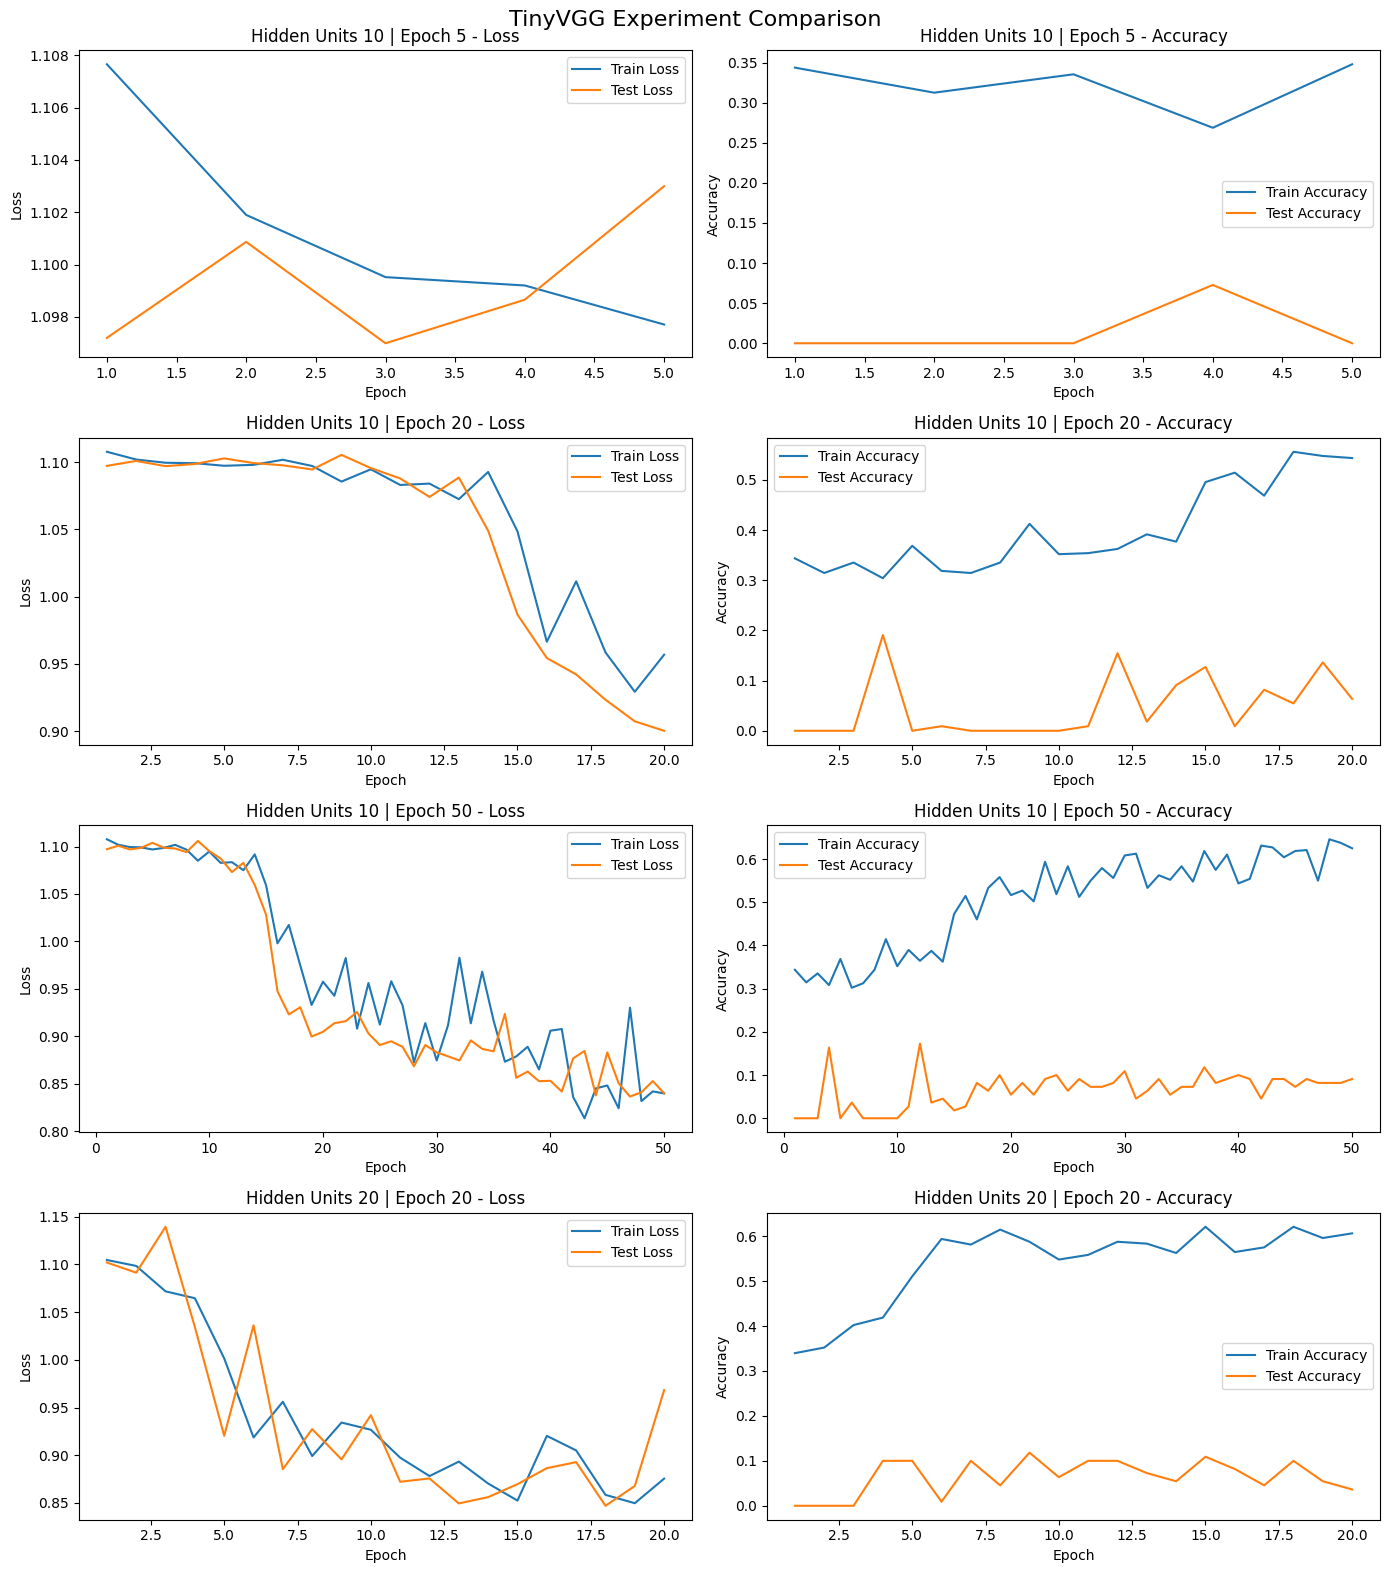

In [26]:
plot_experiment_comparison({
    "Hidden Units 10 | Epoch 5": model_0_results_0,
    "Hidden Units 10 | Epoch 20": model_0_results_1,
    "Hidden Units 10 | Epoch 50": model_0_results_2,
    "Hidden Units 20 | Epoch 20": model_0_results_3,
})

In [27]:
# Download custom image
import requests

# Setup custom image path
custom_image_path = data_path / "pexels-photo-14515106.jpeg"

# Download the image if it doesn't already exist
if not custom_image_path.is_file():
    with open(custom_image_path, "wb") as f:
        request = requests.get("https://images.pexels.com/photos/14515106/pexels-photo-14515106.jpeg")
        print(f"Downloading {custom_image_path}...")
        f.write(request.content)
else:
    print(f"{custom_image_path} already exists, skipping download.")

In [35]:
import torchvision

custom_image_uint8 = torchvision.io.read_image(str(custom_image_path)).type(torch.float32)

custom_image = custom_image_uint8 / 255

print(f"Custom image tensor:\n{custom_image_uint8}\n")
print(f"Custom image shape: {custom_image_uint8.shape}\n")
print(f"Custom image dtype: {custom_image_uint8.dtype}")

Custom image tensor:
tensor([[[ 29.,  34.,  33.,  ..., 100.,  84., 131.],
         [ 27.,  25.,  21.,  ...,  99., 115.,  81.],
         [ 24.,  28.,  30.,  ...,  97., 134., 115.],
         ...,
         [233., 229., 227.,  ...,  14.,  13.,   8.],
         [228., 226., 226.,  ...,   7.,  16.,  26.],
         [232., 233., 235.,  ...,   9.,  11.,  16.]],

        [[  5.,  10.,   9.,  ...,  66.,  50.,  97.],
         [  3.,   1.,   0.,  ...,  65.,  81.,  47.],
         [  0.,   4.,   6.,  ...,  63., 100.,  81.],
         ...,
         [199., 195., 193.,  ...,   6.,   5.,   0.],
         [194., 192., 192.,  ...,   0.,   8.,  18.],
         [198., 199., 201.,  ...,   1.,   3.,   8.]],

        [[  3.,   8.,   7.,  ...,  31.,  15.,  62.],
         [  1.,   0.,   0.,  ...,  30.,  46.,  12.],
         [  0.,   2.,   4.,  ...,  28.,  65.,  46.],
         ...,
         [151., 147., 145.,  ...,   4.,   3.,   0.],
         [146., 144., 144.,  ...,   0.,   6.,  16.],
         [150., 151., 153.,  ...

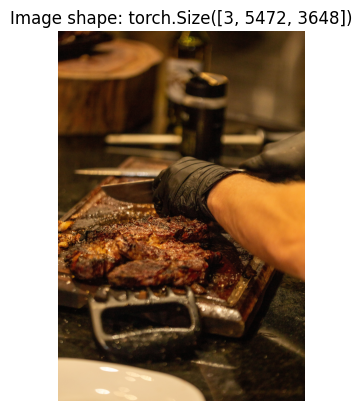

In [37]:
plt.imshow(custom_image.permute(1,2,0))
plt.title(f"Image shape: {custom_image.shape}")
plt.axis(False);

In [38]:
custom_image_transform = transforms.Compose([
  transforms.Resize((64, 64))
])

custom_image_transformed = custom_image_transform(custom_image)

print(f"Original shape: {custom_image.shape}")
print(f"New shape: {custom_image_transformed.shape}")

Original shape: torch.Size([3, 5472, 3648])
New shape: torch.Size([3, 64, 64])


In [39]:
model_0.eval()
with torch.inference_mode():
  custom_image_transformed_with_batch_size = custom_image_transformed.unsqueeze(dim=0)

  print(f"Custom image transformed shape: {custom_image_transformed.shape}")
  print(f"Unsqueezed custom image shape: {custom_image_transformed_with_batch_size.shape}")

  custom_image_pred = model_0(custom_image_transformed.unsqueeze(dim=0).to(device))

Custom image transformed shape: torch.Size([3, 64, 64])
Unsqueezed custom image shape: torch.Size([1, 3, 64, 64])


In [40]:
custom_image_pred

tensor([[-0.7921, -0.2485, -0.3703]], device='cuda:0')

Helper Predict and Plot

In [ ]:
from typing import List

def pred_and_plot_image(model: torch.nn.Module, 
                        image_path: str, 
                        class_names: List[str] = None, 
                        transform=None,
                        device: torch.device = device):
    """Makes a prediction on a target image and plots the image with its prediction."""
    
    # 1. Load in image and convert the tensor values to float32
    target_image = torchvision.io.read_image(str(image_path)).type(torch.float32)
    
    # 2. Divide the image pixel values by 255 to get them between [0, 1]
    target_image = target_image / 255. 
    
    # 3. Transform if necessary
    if transform:
        target_image = transform(target_image)
    
    # 4. Make sure the model is on the target device
    model.to(device)
    
    # 5. Turn on model evaluation mode and inference mode
    model.eval()
    with torch.inference_mode():
        # Add an extra dimension to the image
        target_image = target_image.unsqueeze(dim=0)
    
        # Make a prediction on image with an extra dimension and send it to the target device
        target_image_pred = model(target_image.to(device))
        
    # 6. Convert logits -> prediction probabilities (using torch.softmax() for multi-class classification)
    target_image_pred_probs = torch.softmax(target_image_pred, dim=1)

    # 7. Convert prediction probabilities -> prediction labels
    target_image_pred_label = torch.argmax(target_image_pred_probs, dim=1)
    
    # 8. Plot the image alongside the prediction and prediction probability
    plt.imshow(target_image.squeeze().permute(1, 2, 0)) # make sure it's the right size for matplotlib
    if class_names:
        title = f"Pred: {class_names[target_image_pred_label.cpu()]} | Prob: {target_image_pred_probs.max().cpu():.3f}"
    else: 
        title = f"Pred: {target_image_pred_label} | Prob: {target_image_pred_probs.max().cpu():.3f}"
    plt.title(title)
    plt.axis(False);

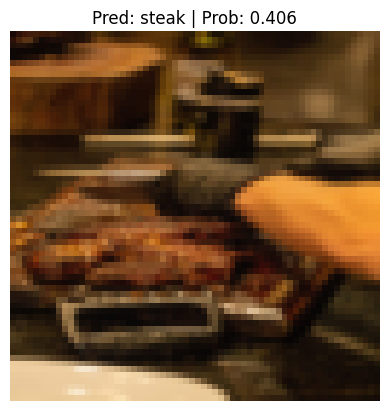

In [42]:
pred_and_plot_image(model=model_0,
                    image_path=custom_image_path,
                    class_names=class_names,
                    transform=custom_image_transform,
                    device=device)

Hasil Benar dimana Gambar Berupa Steak :D
